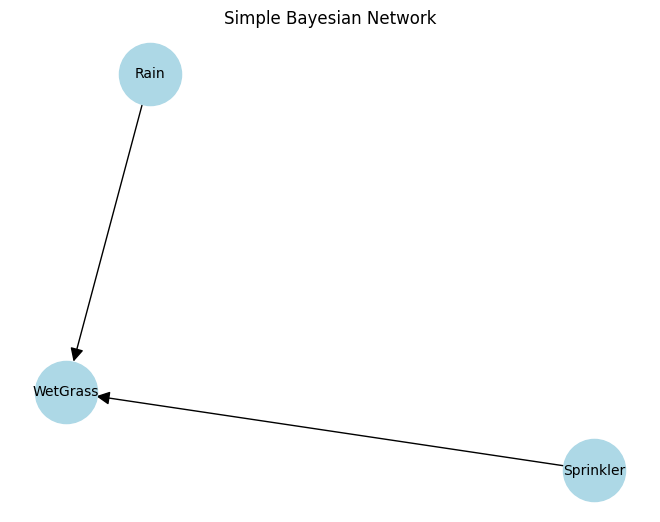

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Example Bayesian Network: Rain → WetGrass ← Sprinkler
G = nx.DiGraph()
G.add_edges_from([("Rain", "WetGrass"), ("Sprinkler", "WetGrass")])

nx.draw(G, with_labels=True, node_color='lightblue', node_size=2000, font_size=10, arrowsize=20)
plt.title("Simple Bayesian Network")
plt.show()


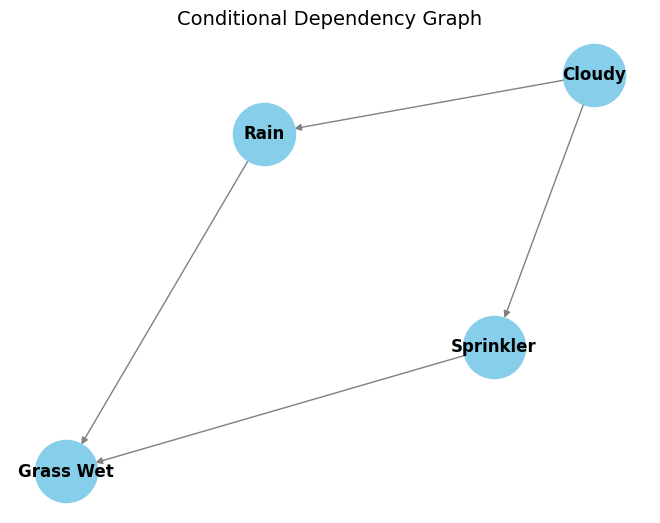

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_conditional_dependency_graph():
    # Create a directed graph
    G = nx.DiGraph()

    # Define variables (nodes)
    variables = ["Rain", "Sprinkler", "Grass Wet", "Cloudy"]

    # Add conditional dependencies (edges)
    dependencies = [
        ("Cloudy", "Rain"),
        ("Cloudy", "Sprinkler"),
        ("Rain", "Grass Wet"),
        ("Sprinkler", "Grass Wet")
    ]

    G.add_nodes_from(variables)
    G.add_edges_from(dependencies)

    # Set up layout
    pos = nx.spring_layout(G, seed=42)

    # Draw nodes, edges, and labels
    nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=2000,
            font_size=12, font_weight='bold', edge_color="gray", arrows=True)

    # Add a title
    plt.title("Conditional Dependency Graph", fontsize=14)
    plt.show()

if __name__ == "__main__":
    draw_conditional_dependency_graph()


In [1]:
# Define a simple probabilistic model manually

# Variables: Rain, Sprinkler, WetGrass
# Dependencies:
#   - Rain affects WetGrass
#   - Sprinkler affects WetGrass

# Define prior and conditional probabilities
P_Rain = 0.2
P_Sprinkler = 0.3

# Conditional probabilities: P(WetGrass | Rain, Sprinkler)
P_WetGrass = {
    (True, True): 0.99,
    (True, False): 0.9,
    (False, True): 0.8,
    (False, False): 0.0
}

# Calculate joint probability and normalize
def joint_probability(rain, sprinkler):
    pwg = P_WetGrass[(rain, sprinkler)]
    pr = P_Rain if rain else 1 - P_Rain
    ps = P_Sprinkler if sprinkler else 1 - P_Sprinkler
    return pwg * pr * ps

# Enumerate all combinations to get total probability of WetGrass = True
total_prob = 0
combinations = [(r, s) for r in [True, False] for s in [True, False]]
for r, s in combinations:
    jp = joint_probability(r, s)
    print(f"P(WetGrass=True, Rain={r}, Sprinkler={s}) = {jp:.4f}")
    total_prob += jp

print(f"\nTotal Probability of WetGrass=True: {total_prob:.4f}")



P(WetGrass=True, Rain=True, Sprinkler=True) = 0.0594
P(WetGrass=True, Rain=True, Sprinkler=False) = 0.1260
P(WetGrass=True, Rain=False, Sprinkler=True) = 0.1920
P(WetGrass=True, Rain=False, Sprinkler=False) = 0.0000

Total Probability of WetGrass=True: 0.3774
